In [117]:
import os
import math 
import missingno as msno
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,auc, confusion_matrix,recall_score, roc_auc_score, roc_curve

In [118]:
path = r"D:\class\Fifth_sem\Data_mining\Data_Minining_Mini_Project\Bank_Marketing_Analysis\Prep_data\Formated_data\combined_additional.csv"
df = pd.read_csv(path)

## Data Understanding

In [119]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [120]:
df['loan'].value_counts()

loan
no         33938
yes         6248
unknown      990
Name: count, dtype: int64

In [121]:
df[df["loan"]=="unknown"][["housing", "y"]].value_counts()

housing  y  
unknown  no     883
         yes    107
Name: count, dtype: int64

In [122]:
df[(df["loan"]=="yes") | (df["loan"]=="no")][["housing", "y"]].value_counts()

housing  y  
yes      no     19064
no       no     16590
yes      yes     2507
no       yes     2025
Name: count, dtype: int64

In [123]:
df.shape

(41176, 21)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

In [125]:
temporal_features = ['month', 'day_of_week']

target_column = ['y']

numeric_features = [col for col in df.select_dtypes('number')
              if col!= temporal_features and col!= target_column]

categorical_features = [col for col in df.select_dtypes('object')
                    if col!= temporal_features and col!= target_column]


numeric_df = df[numeric_features]
categorical_df = df[categorical_features]
temporal_df = df[temporal_features]
target_df = df[target_column]

In [126]:
print(f"Numeric: {len(numeric_features)} | Categorical: {len(categorical_features)} | Temporal: {len(temporal_features)}")

Numeric: 10 | Categorical: 11 | Temporal: 2


In [127]:
numeric_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [128]:
# Calculate the percentage of "unknown" values per column in categorical
def check_unknowns(df):
    unknown_report = {}
    for col in df.columns:
        # Count string "unknown" or actual nulls
        count = (df[col] == 'unknown').sum() + df[col].isnull().sum()
        percentage = (count / len(df)) * 100
        unknown_report[col] = f"{percentage:.2f}%"
    return pd.Series(unknown_report)

print(check_unknowns(categorical_df))

job             0.80%
marital         0.19%
education       4.20%
default        20.88%
housing         2.40%
loan            2.40%
contact         0.00%
month           0.00%
day_of_week     0.00%
poutcome        0.00%
y               0.00%
dtype: object


In [129]:
integrity_issue = df[(df['previous'] == 0) & ((df['pdays'] != 999) | (df['pdays'] != 0))]
print(f'Logical violation found: {len(integrity_issue)}')

Logical violation found: 35551


In [130]:
integrity_issue = df[(df['duration'] == 0) & (df['y'] != 'no')]
print(f'Logical violation found: {len(integrity_issue)}')

Logical violation found: 0


In [131]:
df['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [132]:
integrity_issue = df[(df['poutcome'] == 'success') & (df['previous'] == 0)]
print(f'Logical violation found: {len(integrity_issue)}')

Logical violation found: 0


In [133]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [134]:
outliers_check = df[(df['job'] == 'retired') & (df['age'] <= 63)]
print(f'outliers found in job w.r.t age: {len(integrity_issue)}')

outliers found in job w.r.t age: 0


In [135]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#### Data visualization

<Axes: >

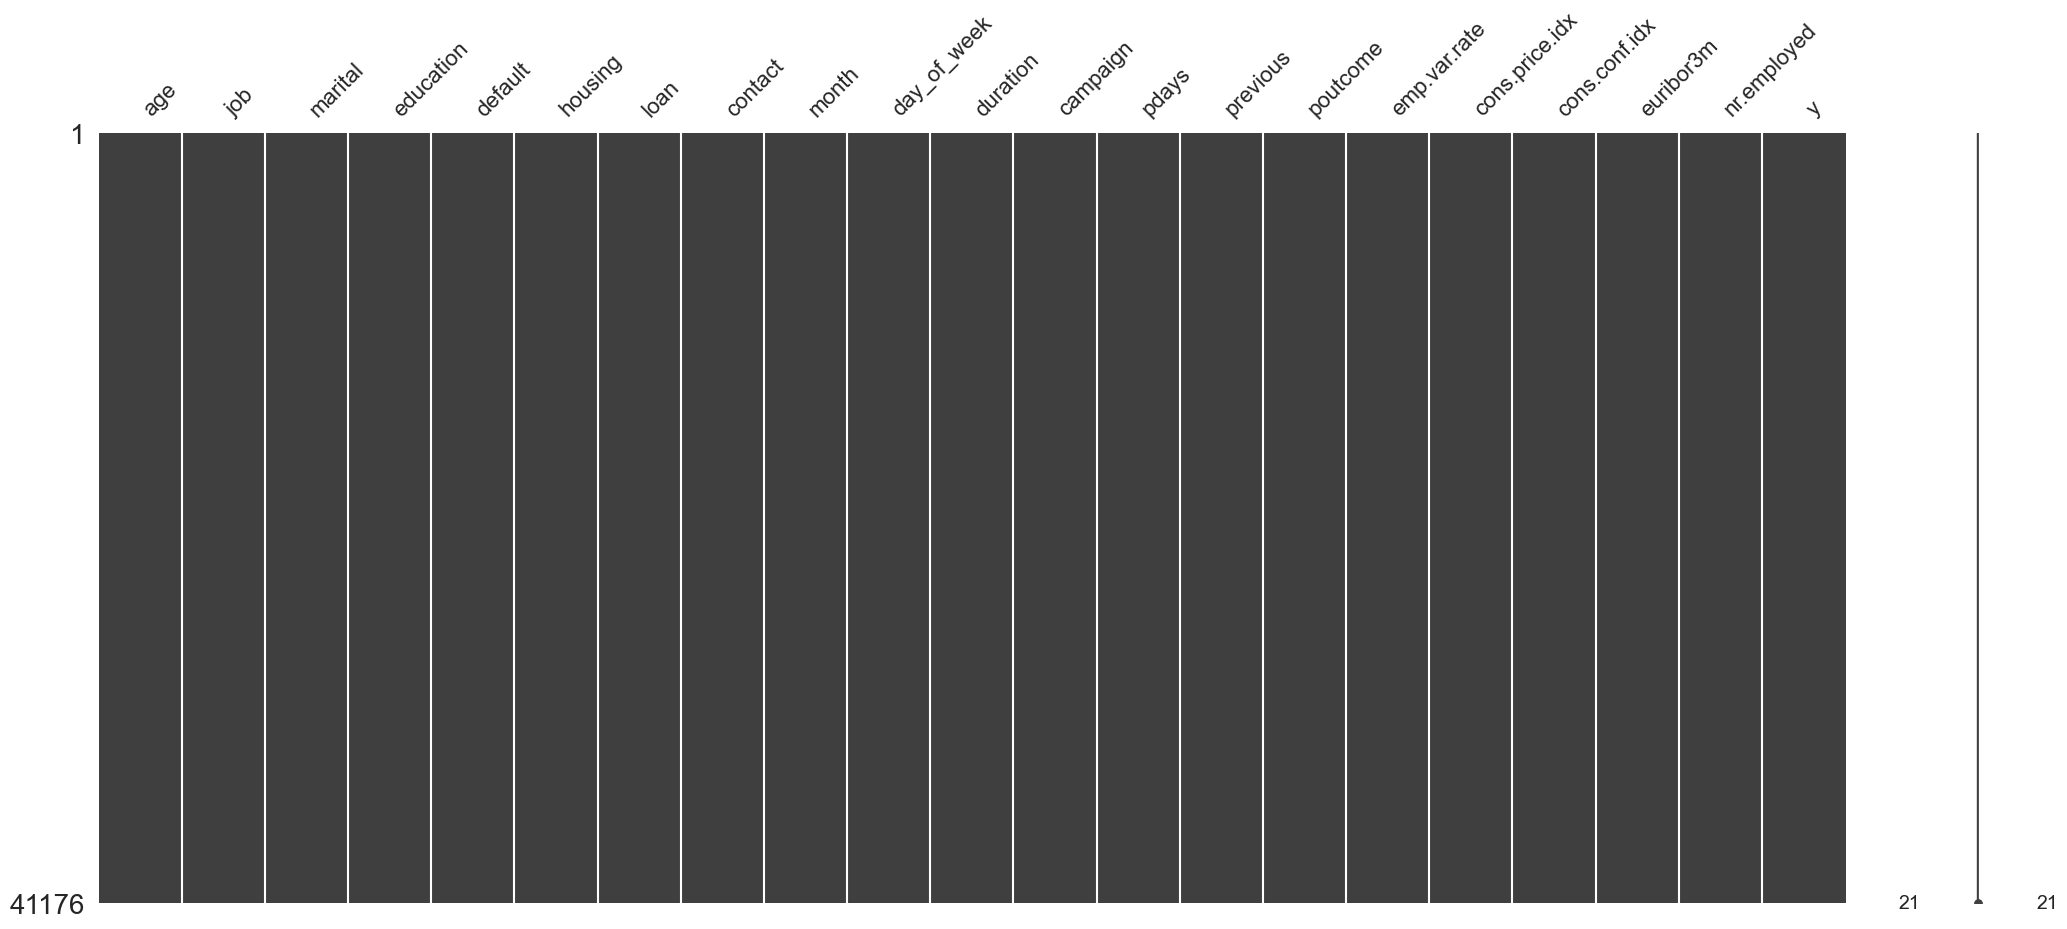

In [136]:
msno.matrix(df)

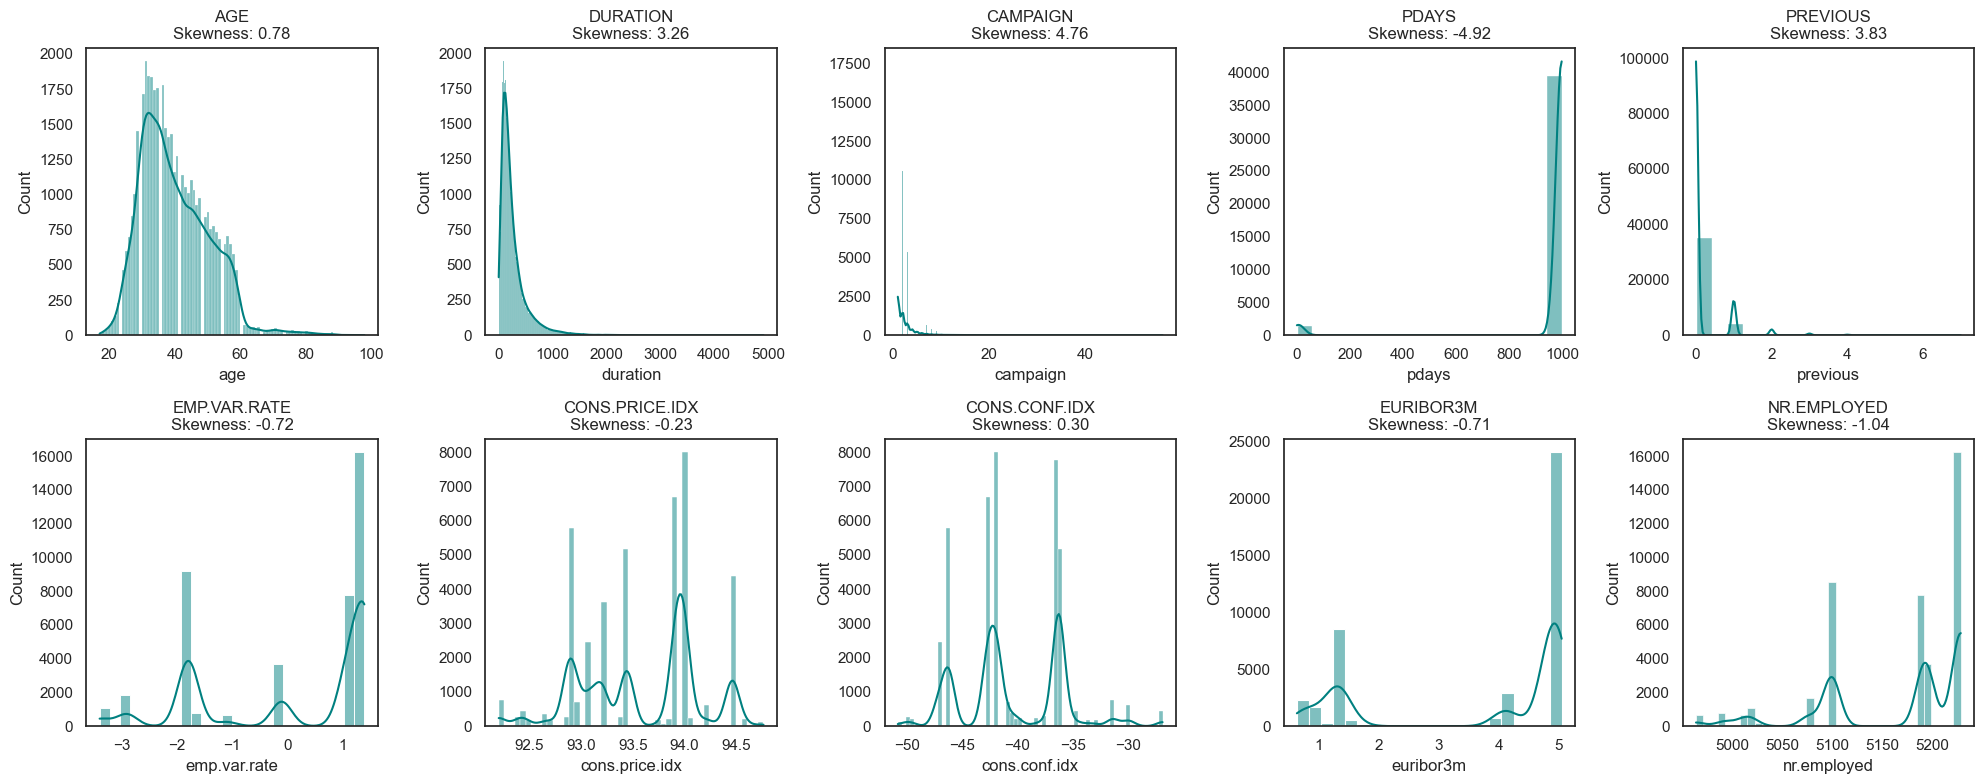

In [137]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
    
def make_KDE_distribution_plot(df, numeric_cols):
    plt.figure(figsize=(20, 8))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, 5, i)  # 2 rows, 5 columns for 10 features
        
        # Combine Histogram with a Kernel Density Estimate (KDE)
        sns.histplot(df[col], kde=True, color='teal')
        
        # Calculate skewness to report in the title
        sk_val = skew(df[col])
        plt.title(f'{col.upper()}\nSkewness: {sk_val:.2f}')
    
    plt.savefig(os.path.join(out_dir, "histplot.png"))
    plt.tight_layout()
    plt.show()

# Execution
make_KDE_distribution_plot(df, numeric_features)

In [138]:
df['marital'].unique().tolist()

['married', 'single', 'divorced', 'unknown']

In [139]:
df['y'].unique().tolist()

['no', 'yes']

In [140]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

def make_pie_plot(df):
    m_labels = ['married', 'single', 'divorced', 'unknown']
    s_labels = ['no', 'yes']
    # Create subplots: use 'domain' type for Pie subplot
    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
    fig.add_trace(go.Pie(labels=m_labels, values=df['marital'].value_counts(), name="Gender"),
                1, 1)
    fig.add_trace(go.Pie(labels=s_labels, values=df['y'].value_counts(), name="Churn"),
                1, 2)

    # Use `hole` to create a donut-like pie chart
    fig.update_traces(hole=.5, hoverinfo="label+percent+name", textfont_size=14)

    fig.update_layout(
        title_text="Marital and Subscribtion Distributions",
        # Add annotations in the center of the donut pies.
        annotations=[dict(text='marital', x=0.15, y=0.5, font_size=20, showarrow=False),
                    dict(text='Subscribe', x=0.86, y=0.5, font_size=20, showarrow=False)])
    fig.write_image(os.path.join(out_dir, "Gender and subscribtion.png"))
    fig.show()

# Execution
make_pie_plot(df)

- Total positive subscribtion out of all marketing campign is only 11.3% from May 2008 to November 2010.
- Out of total data, 60.5% custumers were married(highest), 28.1% were single, 11.2% were divorced and 0.194% custumers marital status were unknown.
- The total volume of "no" responses vastly outweighs the "yes" responses, indicating a highly skewed target variable

In [141]:
df['y'][df['y']=='no'].groupby(by= df['marital']).value_counts().tolist()

[4135, 22390, 9944, 68]

In [142]:
df['y'][df['y']=='yes'].groupby(by= df['marital']).value_counts().tolist()

[476, 2531, 1620, 12]

In [143]:
df['y'].value_counts()

y
no     36537
yes     4639
Name: count, dtype: int64

In [144]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Histogram'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

fig = px.histogram(df, x="y", color="marital", barmode="group", title="<b>Marital distribution w.r.t subscribtion<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Marital distribution with subscribtion.png"))

fig.show()

- While "Married" has the highest count but "Single" individuals might actually have a higher probability of saying yes.
- since, the unknown category is very small in comparision to other we can impute it later rather than keeping it as seperate class.

In [145]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

df_viz = df.copy()
df_viz['poutcome_combined'] = df_viz['poutcome'].replace({'failure': 'contacted', 'success': 'contacted', 'nonexistent':'not-contracted'})

labels = df_viz['poutcome_combined'].unique()
print(labels)
values = df_viz['poutcome_combined'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Privous Contract Distribution</b>")
fig.write_image(os.path.join(out_dir, "Privous contract distribution.png"))

fig.show()


['not-contracted' 'contacted']


- most of the custumers were just contracted in this campagin only(86.3%) i.e. no previous contractual relationship or contact with the bank and only 13.7% of custumers were old custumers.

- So this campaign was mainly operated for on new Customer acquisition rather than existing clients.

In [146]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
labels = df['poutcome'].unique()
values = df['poutcome'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Privous outcome Distribution</b>")
fig.write_image(os.path.join(out_dir, "Privous outcome distribution.png"))

fig.show()

- Non-existent category dominant the Poutcome with 86.3%(most of cusumers were newcomers), where 

In [147]:
out_dir = "Report\\EDA\\10_Bivariant_Analysis//Histogram"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
    
fig = px.histogram(df, x="y", color="poutcome", title="<b>previous Customer distribution w.r.t. y</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Previous customer distribution with subscribtion.png"))

fig.show()

- Most customers have a "nonexistent" history and they have very less success rate than failure.
- Custumer who previously fail to subscribe are significantly more likely to decline in next campaign too, though a small portion do eventually convert to a "yes".
- If previous outcome was a success than they are more like to subscribe rather than fail in next campaign.


In [148]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

labels = df['housing'].unique()
values = df['housing'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Housing loan Distribution</b>")
fig.write_image(os.path.join(out_dir, "Housing loan Distribution.png"))

fig.show()

- Custumer with both housing loan and without loan are balanced. Out of which, 2.4% customers housing loan detail are unknown.

In [149]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Histogram'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
fig = px.histogram(df, x="y", color="housing", title="<b>Housing Loan distribution w.r.t. Subscribtion</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Housing Loan distribution with Subscribtion.png"))

fig.show()

- In both cases, the "yes" and "no" subscription categories, individuals with housing loans (orange) represent a larger portion of the population than those without them (blue).
- That is, having a housing loan does not appear to be a strong indicator of subscription success.
- The "unknown" category (green) is a negligible at the top of both bars i.e it has minimal effect at subscribtion so we can impute it rather than keeping it as seperate category.

In [150]:
numeric_df.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [151]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

labels = df['loan'].unique()
values = df['loan'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Perosnal Loan Distribution</b>")
fig.write_image(os.path.join(out_dir, "Perosnal Loan Distribution.png"))

fig.show()

- Out of total custumer, most of them doesn't possesses any types of loan(84.4%) and only 15.2% of the group responded "yes" to having a loan.
- A small fraction of the data (2.4%) is categorized as "unknown"

In [152]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Histogram'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="y", color="loan", barmode="group", title="<b>Subscribtion distribution w.r.t. Perosnal Loan</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Subscribtion distribution w.r.t. Perosnal Loan.png"))

fig.show()

- In both cases, the "yes" and "no" subscription categories, individuals with no personal loan represent a larger portion of the population than those with personal loan i.e. persoanl loan alone can be disministic factor here.
- But the person without personal loan are significantly more likely to subscribe rather than those who who has persoanl loan.
- The unknown value is still relatively small in comparable to other category.(so we can perform imputation)

In [153]:
df['default'].value_counts()

default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

In [154]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

labels = df['default'].unique()
values = df['default'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Default Credit  Distribution</b>")
fig.write_image(os.path.join(out_dir, "Default Credit  Distribution.png"))

fig.show()

- most of the custumers in the current campaign has no credit in default.
- A significant portion of the data is marked as unknown which is the major insights and we can treat it as an own category rather than imputing or deleting unknown value cause it can hold the insight such as people new to credit or they choose not to expose or  data are just simply missing?
- And almost invisible number of custumers have credit in default.

In [155]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Histogram'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

fig = px.histogram(df, x="y", color="default", title="<b>Default Credit Distribution w.r.t. Subscribtion</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Default Credit Distribution w.r.t. Subscribtion.png"))

fig.show()

- most of the custumers have no credit in default and the custumer with no credit is dominant in both subscribtion category.
- person with a credit in default is almost gurantted to not subscribe.
- A significant portion of the data is missing default information.
- Also custumers with no credit cards is significantly highly likely to accept the subscribtion in compare to those who have credit in default.
- Because the "yes" category for defaults is so minuscule, a predictive model will struggle to learn its characteristics without specific balancing techniques.

In [156]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

labels = df['job'].unique()
values = df['job'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Job Distribution</b>")
fig.write_image(os.path.join(out_dir, "Job  Distribution.png"))

fig.show()


- Job category is quite diverse rather than the other field.
- Top 3 Roles: Housemaids (26.1%), Service workers (22.5%), and Admin staff (16.4%) make up over 65% of the total dataset.
- Minority Groups: Students (2.13%) and Entrepreneurs (2.46%) represent the smallest portions of the demographic.

In [157]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Histogram'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

fig = px.histogram(df, x="y", color="job",barmode="group",  title="<b>Subscribtion distribution w.r.t. Jobs</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Subscribtion distribution w.r.t. Jobs.png"))

fig.show()

- High Volume, High Rejection: The "Admin" and "Blue-collar" categories have the highest total counts, but the vast majority of them (the "0" group) did not subscribe.
- There is a massive imbalance. For every job category, the number of people who refused subscribtion is significantly higher than those who accepted. This suggests a low overall conversion rate for the campaign across all professions.

In [158]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Histogram'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

fig = px.histogram(df, x="y", color="month",barmode="group",  title="<b>Subscribtion distribution w.r.t. months</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Subscribtion distribution w.r.t. months.png"))

fig.show()


- The month of May shows the highest level of activity by far, with nearly 13,000 non-subscriptions (0). While it also has the highest number of absolute successes i.e. its conversion rate is quite low compared to the massive volume of outreach.

- The months of May, June, July, and August represent the bulk of the campaign's efforts. After August, there is a significant drop-off in contact volume.

- Months like October, December, March, and September have very small bars in non-subscription category, but their success bars in the subscribe category are nearly as tall as their rejection bars i.e. fewer people were contacted in these months, they were much more likely to subscribe.

In [159]:
out_dir = 'Report\\EDA\\00_Univariant_Analysis\\Pie_charts'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

labels = df['education'].unique()
values = df['education'].value_counts()
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>education Distribution</b>")
fig.write_image(os.path.join(out_dir, "education distribution.png"))

fig.show()

- Most of the contracted custumers have basic 4 years of educational backgroud which usually means his primary education in Portugal.
- most custumer falls into basic or high-school education i.e. our data is skewed moderate education.
- 5.6% of total are label as unknown which considerable amount.
- Education levels are ordinal, but here they are similar educational group are treated as hierarchy .for eg: we can't treat custumer with basic.6y education differently from basic.9y.So, we can merge it later on

In [160]:
df['loan'].value_counts()

loan
no         33938
yes         6248
unknown      990
Name: count, dtype: int64

In [161]:
df['housing'].value_counts()

housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

In [162]:
df[df["loan"]=="no"][["housing", "y"]].value_counts()

housing  y  
yes      no     15782
no       no     14307
yes      yes     2098
no       yes     1751
Name: count, dtype: int64

In [163]:
df[df["loan"]=="yes"][["housing", "y"]].value_counts()


housing  y  
yes      no     3282
no       no     2283
yes      yes     409
no       yes     274
Name: count, dtype: int64

In [164]:
df[df["loan"]=="unknown"][["housing", "y"]].value_counts()

housing  y  
unknown  no     883
         yes    107
Name: count, dtype: int64

In [165]:
import os
import plotly.graph_objects as go

out_dir = "Report\\EDA\\20_Multivariant_Analysis\\Histogram"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

fig = go.Figure()

# Loan = no
fig.add_trace(go.Bar(
    x=[['y:No', 'y:No', 'y:Yes', 'y:Yes'],
       ['housing:no', 'housing:yes', 'housing:no', 'housing:yes']],
    y=[14307, 15782, 1751, 2098],
    name='Loan: No',
))

# Loan = yes
fig.add_trace(go.Bar(
    x=[['y:No', 'y:No', 'y:Yes', 'y:Yes'],
       ['housing:no', 'housing:yes', 'housing:no', 'housing:yes']],
    y=[2283, 3282, 274, 409],
    name='Loan: Yes',
))

fig.update_layout(
    title_text="<b>y Distribution w.r.t. Housing and Loan</b>",
    barmode='group',
    xaxis_title="Subscribe and Housing",
    yaxis_title="Count"
)

fig.write_image(os.path.join(out_dir, "Y Distribution w.r.t loan and housing.png"), width=600, height=600, scale=2)
fig.show()

- When a significant portion of a client's income is tied up in mortgage payments, they have less disposable liquidity to "lock away" in a long-term savings product.
- High-pressure sales for savings products are often less effective for this segment than products focused on debt management or refinancing.
- Since the subscribtion rate is very small we can conclude that this dataset is based of "middle-class" demographic region.
- while comparing the sucess rate while if a client doesn't have a loan, the "default" expectation is still a "No." However, having a loan (especially a personal one) makes that "No" much more certain.

In [166]:
df[(df['housing']=='yes') & (df['loan']=='yes') & df['y']=='yes'].shape

(0, 21)

In [167]:
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [168]:
df['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [169]:
df['loan'].unique()

array(['no', 'yes', 'unknown'], dtype=object)

In [170]:
df[df["loan"]=="yes"][["marital", "y"]].value_counts()

marital   y  
married   no     3399
single    no     1552
divorced  no      603
married   yes     374
single    yes     236
divorced  yes      72
unknown   no       11
          yes       1
Name: count, dtype: int64

In [171]:
df[df["loan"]=="no"][["marital", "y"]].value_counts()

marital   y  
married   no     18463
single    no      8151
divorced  no      3419
married   yes     2097
single    yes     1345
divorced  yes      396
unknown   no        56
          yes       11
Name: count, dtype: int64

In [172]:
out_dir = "Report\\EDA\\20_Multivariant_Analysis\\Histogram"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

fig = go.Figure()

# Married
fig.add_trace(go.Bar(
    x=[['y:No', 'y:Yes', 'y:No', 'y:Yes'],
       ['loan:no', 'loan:no', 'loan:yes', 'loan:yes']],
    y=[18463, 2097, 3399, 374, 56, 11],
    name='Married',
))

# Single
fig.add_trace(go.Bar(
    x=[['y:No', 'y:Yes', 'y:No', 'y:Yes'],
       ['loan:no', 'loan:no', 'loan:yes', 'loan:yes']],
    y=[8151, 1345, 1552, 236, 56, 11],
    name='Single',
))

# Divorced
fig.add_trace(go.Bar(
    x=[['y:No', 'y:Yes', 'y:No', 'y:Yes'],
       ['loan:no', 'loan:no', 'loan:yes', 'loan:yes']],
    y=[3419, 396, 603, 72, 56, 11],
    name='Divorced',
))


fig.update_layout(
    title_text="<b>y Distribution w.r.t. Marital Status and loan</b>",
    barmode='group',
    xaxis_title="Subscribe and Loan",
    yaxis_title="Count"
)

fig.write_image(os.path.join(out_dir, "Y Distribution w.r.t loan and martial.png"), width=600, height=600, scale=2)

fig.show()

- low overall conversion rate for this specific campaign , regardless of marital status or loan standing.
- In the subscribtion group, the counts for people with no loan are significantly higher than those with loan:yes.
- Married individuals are the largest demographic across all categories.They represent highest num of non-subscriber but also highest count of subscriber.But the convergence rate for custumer with no loan and single is comparitively greater than custumers with no loan and single.


In [173]:
# Find the mode of the 'marital' column (excluding 'unknown')
marital_mode = df.loc[df['marital'] != 'unknown', 'marital'].mode()[0]

print(marital_mode)
# Replace 'unknown' with the mode
df.loc[df['marital'] == 'unknown', 'marital'] = marital_mode

married


In [174]:
df['marital'].value_counts()

marital
married     25001
single      11564
divorced     4611
Name: count, dtype: int64

In [175]:
education_map = {
        'basic.4y': 'low', 'basic.6y': 'low', 'basic.9y': 'medium',
        'high.school': 'medium', 'professional.course': 'high',
        'university.degree': 'high', 'unknown': 'unknown', 'illiterate': 'unknown'
    }

df['education'] = df['education'].map(education_map)

In [176]:
df['education'].value_counts()

education
high       17404
medium     15557
low         6467
unknown     1748
Name: count, dtype: int64

In [177]:
education_order = df['education'].value_counts(ascending=True).index.tolist()
education_order

['unknown', 'low', 'medium', 'high']

In [178]:

out_dir = "Report\\EDA\\10_Bivariant_Analysis\\Histogram"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

color_map = {"Yes": "#FF97FF", "No": "#AB63FA"} 
education_order = df['education'].value_counts(ascending=True).index.tolist()

fig = px.histogram(
    df,
    x="y",
    color="education",
    barmode="group",
    category_orders={"education": education_order},
    title="<b>Y Distribution w.r.t education</b>",
    color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Y Distribution w.r.t education.png"))
fig.show()



In [179]:
df['education'].value_counts()

education
high       17404
medium     15557
low         6467
unknown     1748
Name: count, dtype: int64

In [180]:

out_dir = "Report\\EDA\\10_Bivariant_Analysis\\Histogram"
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

color_map = {"Yes": "#FF97FF", "No": "#AB63FA"} 
order = df['day_of_week'].value_counts(ascending=True).index.tolist()

fig = px.histogram(
    df,
    x="y",
    color="day_of_week",
    barmode="group",
    category_orders={"day_of_week": order},
    title="<b>Y Distribution w.r.t day_of_week</b>",
    color_discrete_map=color_map
)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.write_image(os.path.join(out_dir, "Y Distribution w.r.t day_of_week.png"))
fig.show()

In [181]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [182]:
numeric_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [183]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Density_plot'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
    
# 1. Filter the 'previous' data for both outcomes
yes_dist = df[df['y'] == 'yes']['cons.price.idx']
no_dist = df[df['y'] == 'no']['cons.price.idx']

# 2. Group the data and labels
hist_data = [yes_dist, no_dist]
group_labels = ['Subscribed (Yes)', 'Not Subscribed (No)']
colors = ['#3498db', '#e74c3c'] # Blue and Red similar to your reference

# 3. Create the Distplot with only the KDE curve (hide histogram/rug)
fig = ff.create_distplot(
    hist_data, 
    group_labels, 
    show_hist=False, 
    show_rug=False,
    colors=colors
)

# 4. Stylize the layout
fig.update_layout(
    title='Distribution of cons.price.idx by Campaign Result',
    xaxis_title='cons.price.idx',
    yaxis_title='Density',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.write_image(os.path.join(out_dir, "Distribution of cons.price.idx by Campaign Result.png"))

fig.show()

- When the cost of living index hits this specific range, there is a very high density of rejections. In contrast, the "Subscribed" curve is much flatter and lower in this same region, suggesting that high-CPI periods are particularly difficult for closing sales.
- Non-Subscribers (Red): This group shows extreme "peakiness." Their refusals are highly concentrated at specific economic markers (around 92.9, 93.4, 94.0, and 94.5). These represent "danger zones" for your campaign.

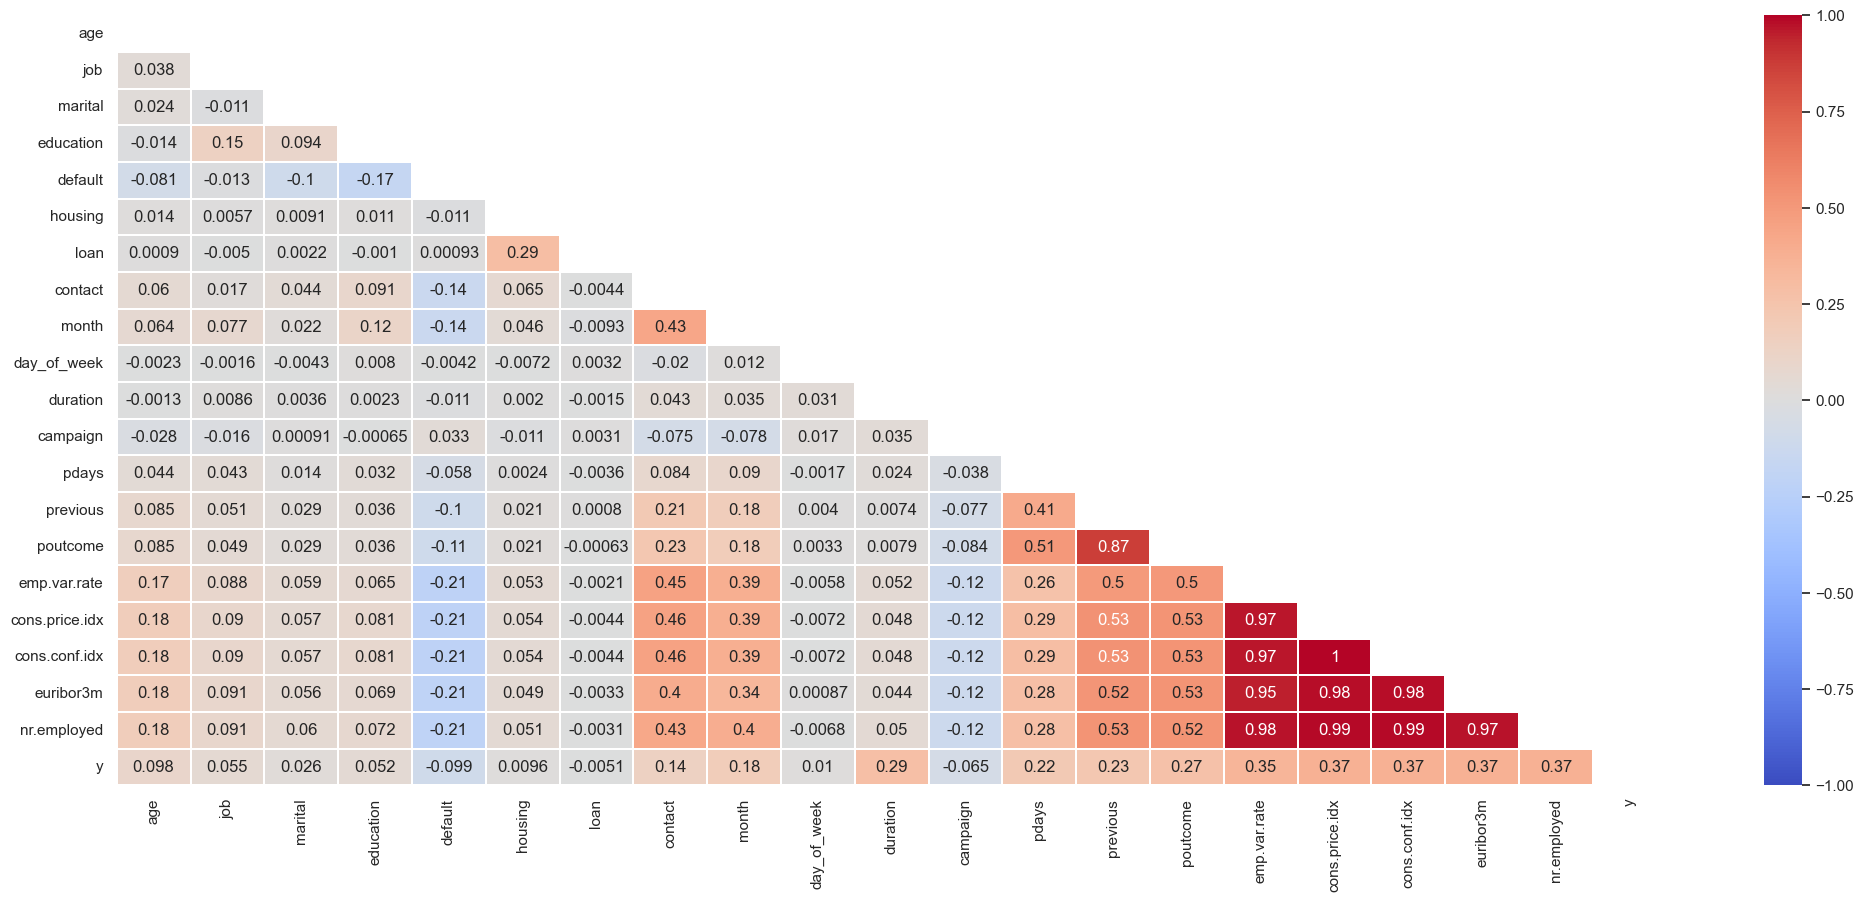

In [184]:
out_dir = 'Report\\EDA\\20_Multivariant_Analysis\\Correlation_heatmap'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

plt.savefig(os.path.join(out_dir, "corr_heatmap.png"))
plt.show()


- we can clealy visualize that social and economic context attributes is highly correlated with subscribition.
- 

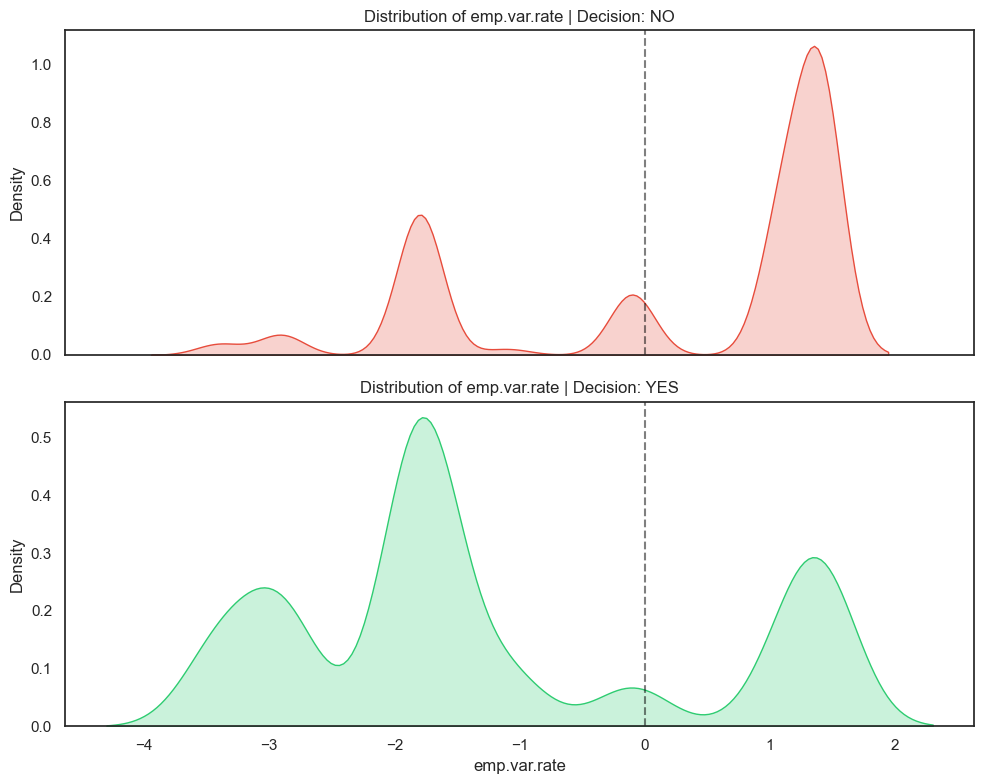

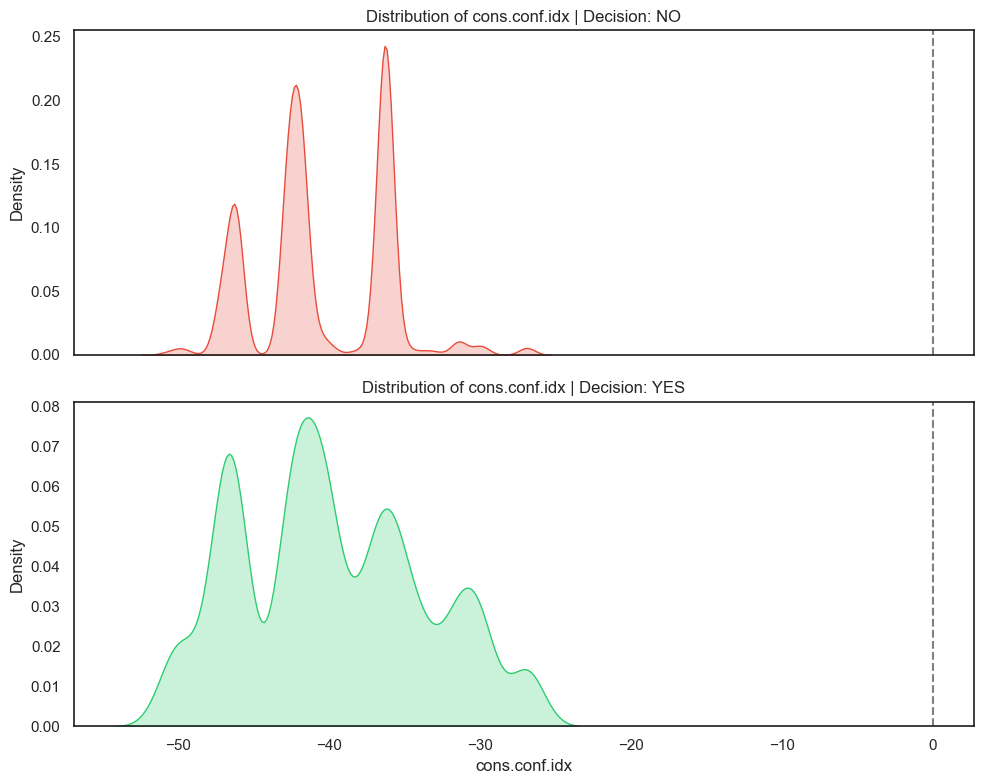

In [185]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Density_Plot'

idx_cols = ['emp.var.rate', 'cons.conf.idx']

for col in idx_cols:
    # Create a stack of 2 plots for the specific index
    fig, (ax_no, ax_yes) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Top Plot: Decision NO
    sns.kdeplot(data=df[df['y'] == 'no'], x=col, fill=True, color='#e74c3c', ax=ax_no)
    ax_no.set_title(f'Distribution of {col} | Decision: NO')
    ax_no.axvline(0, color='black', linestyle='--', alpha=0.5) # Reference line at 0
    
    # Bottom Plot: Decision YES
    sns.kdeplot(data=df[df['y'] == 'yes'], x=col, fill=True, color='#2ecc71', ax=ax_yes)
    ax_yes.set_title(f'Distribution of {col} | Decision: YES')
    ax_yes.axvline(0, color='black', linestyle='--', alpha=0.5) # Reference line at 0
    plt.savefig(os.path.join(out_dir, f"kde_plot_{col}.png"))
    plt.tight_layout()
    plt.show()

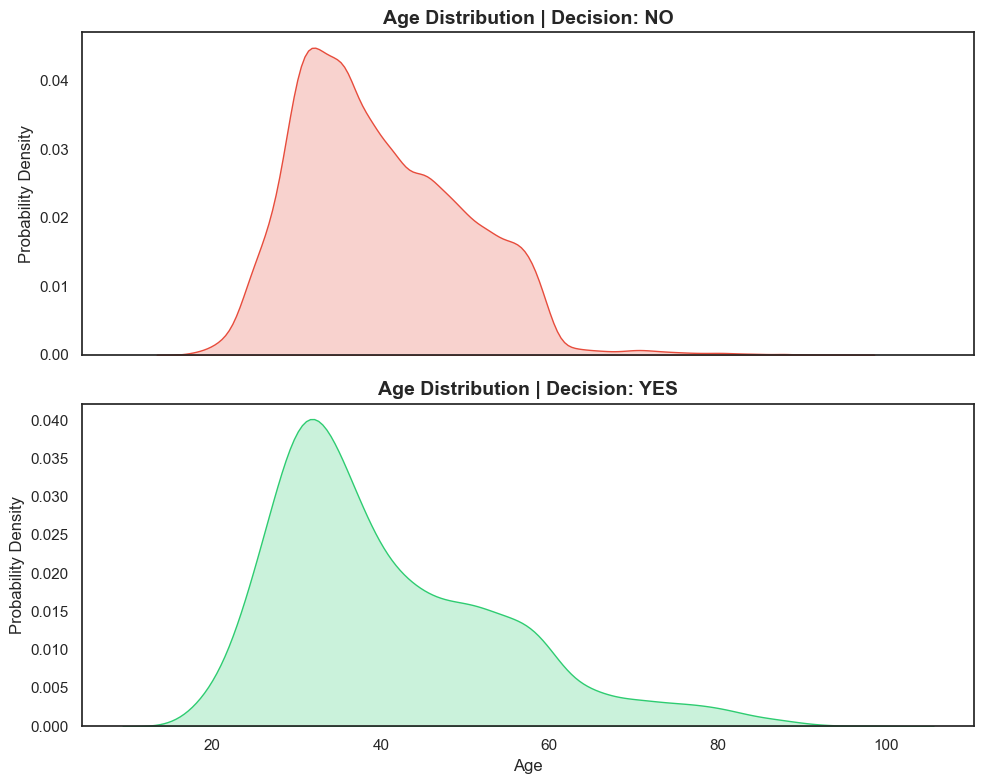

In [186]:
out_dir = 'Report\\EDA\\10_Bivariant_Analysis\\Density_plot'

# Set the visual style
sns.set_theme(style="white")

# Create a figure with 2 rows and 1 column, sharing the X-axis
fig, (ax_no, ax_yes) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Customers who said "NO"
sns.kdeplot(data=df[df['y'] == 'no'], x='age', fill=True, color='#e74c3c', ax=ax_no)
ax_no.set_title('Age Distribution | Decision: NO', fontsize=14, fontweight='bold')
ax_no.set_ylabel('Probability Density')

# Bottom Plot: Customers who said "YES"
sns.kdeplot(data=df[df['y'] == 'yes'], x='age', fill=True, color='#2ecc71', ax=ax_yes)
ax_yes.set_title('Age Distribution | Decision: YES', fontsize=14, fontweight='bold')
ax_yes.set_ylabel('Probability Density')
ax_yes.set_xlabel('Age')

# Clean up layout
plt.tight_layout()
plt.savefig(os.path.join(out_dir, f"kde_plot_age_distribution.png"))
plt.show()

-  Age distribution of non-Subscribed custumers drops off sharply after age 60 and is more tightly clustered. In contrast, Age distribution of subscribed custumers is a much "fatter" and longer tail extending toward age 80 and beyond and more spread.

C:\Users\nisch\AppData\Local\Temp\ipykernel_11844\2661038014.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




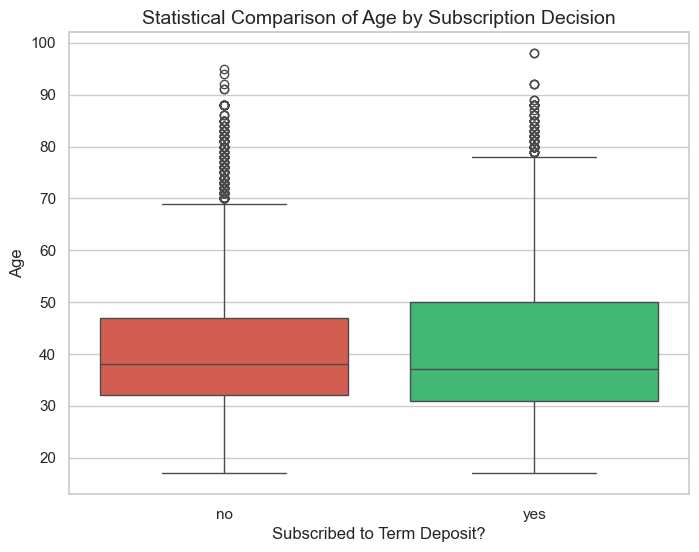

In [187]:
out_dir = 'Report\\EDA\\10_Univariant_Analysis\\Boxplot'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

# Set style for a clean look
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# Create the boxplot
sns.boxplot(data=df, x='y', y='age', palette={'yes': '#2ecc71', 'no': '#e74c3c'})

# Adding titles and labels
plt.title('Statistical Comparison of Age by Subscription Decision', fontsize=14)
plt.xlabel('Subscribed to Term Deposit?', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.savefig(os.path.join(out_dir, "box_plot_of_age.png"))
plt.show()

- If we only looked at the "average" customer, you wouldn't see a difference. The decision to subscribe to a term deposit isn't driven by the typical middle-aged person but rather by the behavior of the age extremes.
- The "No" Group: Features a dense cluster of outliers starting around age 70 and stopping abruptly at age 95 where as  "Yes" Group features outliers that are more spread out, including the highest data point in the set (nearing age 100).
- The bottom whiskers for both groups end at exactly the same spot, around age 18 i.e. there is a hard floor at the legal adult age, and neither group has outliers on the "young" side. The variance is strictly happening among the older population.

## Data Cleaning

In [188]:
categorical_df.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no


In [189]:
#  for the given input we don't know the duration call already as if so we would have already know the result at the end of the everycall so no use in predictive modeling.
# If included it create data leakage i.e. when information from the future (the outcome) is included in the training data used to predict that outcome.
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})
print(df['duration'].corr(df['y_binary']))
df.drop(columns=['y_binary'], inplace= True)
df.drop(columns=['duration'], inplace= True)


0.40529726126852406


In [190]:
# Create a new column to check if the client was ever contracted before this campaign or not
df['is_previously_contracted'] = (df['pdays']!=999).astype(bool)
df['pdays'] = df['pdays'].replace(999, 0)

In [191]:
df['is_previously_contracted'].value_counts()

is_previously_contracted
False    39661
True      1515
Name: count, dtype: int64

In [192]:
df['is_previously_contracted'].value_counts()

is_previously_contracted
False    39661
True      1515
Name: count, dtype: int64

In [193]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,is_previously_contracted
9136,27,services,single,high,no,no,no,telephone,jun,fri,...,0,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,no,False
30492,30,unemployed,married,medium,no,yes,no,cellular,may,mon,...,3,1,success,-1.8,92.893,-46.2,1.354,5099.1,yes,True
2821,41,admin.,single,high,no,yes,no,telephone,may,wed,...,0,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,no,False
49,45,blue-collar,married,medium,no,yes,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
36361,41,technician,married,high,no,no,no,cellular,jun,tue,...,0,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,yes,False


In [194]:
df['is_previously_contracted'] = (df['pdays']!=999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)

In [195]:
df['is_previously_contracted'].unique

<bound method Series.unique of 0        1
1        1
2        1
3        1
4        1
        ..
41171    1
41172    1
41173    1
41174    1
41175    1
Name: is_previously_contracted, Length: 41176, dtype: int64>

In [196]:
df['marital'].value_counts(ascending=True)

marital
divorced     4611
single      11564
married     25001
Name: count, dtype: int64

In [197]:
bins = [0, 25, 40, 60, 100]
labels = ['Young', 'Adult', 'Senior', 'Elderly']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

In [198]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,is_previously_contracted,age_group
0,56,housemaid,married,low,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior
1,57,services,married,medium,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior
2,37,services,married,medium,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Adult
3,40,admin.,married,low,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior
4,56,services,married,medium,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior


In [199]:
df.drop(columns=['age', 'contact', 'pdays'], inplace= True)

In [200]:
# Calculate the percentage of "unknown" values per column in categorical
def check_unknowns(df):
    unknown_report = {}
    for col in df.columns:
        # Count string "unknown" or actual nulls
        count = (df[col] == 'unknown').sum() + df[col].isnull().sum()
        percentage = (count / len(df)) * 100
        unknown_report[col] = f"{percentage:.2f}%"
    return pd.Series(unknown_report)

check_unknowns(df.select_dtypes('object'))

job             0.80%
marital         0.00%
education       4.25%
default        20.88%
housing         2.40%
loan            2.40%
month           0.00%
day_of_week     0.00%
poutcome        0.00%
y               0.00%
dtype: object

In [201]:
to_impute = ['job', 'education', 'housing', 'loan', 'previous']

In [202]:
def impute_value(feature):
    feature_mode = df.loc[df[feature] != 'unknown', feature].mode()[0]
    print(feature_mode)
    df.loc[df[feature] == 'unknown', feature] = feature_mode

for feature in to_impute:
    impute_value(feature)

admin.
high
yes
no
0


In [203]:
# Calculate the percentage of "unknown" values per column in categorical
def check_unknowns(df):
    unknown_report = {}
    for col in df.columns:
        # Count string "unknown" or actual nulls
        count = (df[col] == 'unknown').sum() + df[col].isnull().sum()
        percentage = (count / len(df)) * 100
        unknown_report[col] = f"{percentage:.2f}%"
    return pd.Series(unknown_report)

check_unknowns(df.select_dtypes('object'))

job             0.00%
marital         0.00%
education       0.00%
default        20.88%
housing         0.00%
loan            0.00%
month           0.00%
day_of_week     0.00%
poutcome        0.00%
y               0.00%
dtype: object

In [204]:
df.head()

,job,marital,education,default,housing,loan,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,is_previously_contracted,age_group
0,housemaid,married,low,no,no,no,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior
1,services,married,medium,unknown,no,no,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior
2,services,married,medium,no,yes,no,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Adult
3,admin.,married,low,no,no,no,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior
4,services,married,medium,no,no,yes,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,Senior


## Data Preprocessing

In [205]:
df.drop(columns=['previous'], inplace=True)

In [206]:
df['y'].value_counts()

y
no     36537
yes     4639
Name: count, dtype: int64

In [207]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [208]:
df['y'].value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

In [209]:
X = df.drop(columns=['y'])
y = df['y']

In [210]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [211]:
df['education'].unique().tolist()

['low', 'medium', 'high']

In [212]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Example column lists (update with your actual column names)
num_cols = ['campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
nominal_cols = ['job', 'marital', 'month', 'day_of_week', 'default', 'housing', 'loan']
ordinal_cols = ['education']

# Define the order for ordinal columns (example for education)'basic', 'high schoo
education_order = education_order = [['low', 'medium', 'high', 'unknown']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('nom', OneHotEncoder(), nominal_cols),
        ('ord', OrdinalEncoder(categories=education_order), ordinal_cols)
    ]
)

In [213]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['campaign', 'emp.var.rate', 'cons.price.idx',
                                  'cons.conf.idx', 'euribor3m',
                                  'nr.employed']),
                                ('nom', OneHotEncoder(),
                                 ['job', 'marital', 'month', 'day_of_week',
                                  'default', 'housing', 'loan']),
                                ('ord',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high',
                                                             'unknown']]),
                                 ['education'])])

In [214]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [215]:
# Check number of samples in train and test sets
print("X_train:", X_train.shape[0])
print("X_test:", X_test.shape[0])
print("y_train:", y_train.shape[0])
print("y_test:", y_test.shape[0])

X_train: 32940
X_test: 8236
y_train: 32940
y_test: 8236


## Modeling

#### Logistic Regression

In [216]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_processed, y_train)

#predict and evaluate
y_pred = model.predict(X_test_processed)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.85      0.90      7265
           1       0.36      0.61      0.45       971

    accuracy                           0.82      8236
   macro avg       0.65      0.73      0.67      8236
weighted avg       0.87      0.82      0.84      8236



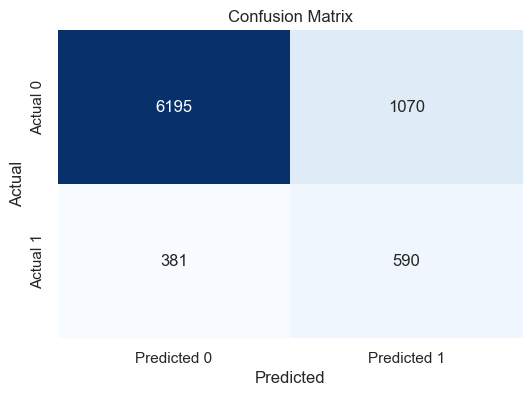

In [217]:
out_dir = 'Report\\Evaluation\\confusion_metircs'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

cm = confusion_matrix(y_test, y_pred)   
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(out_dir, "confusion_matrix_of_LogisticRegression.png"))
plt.show()

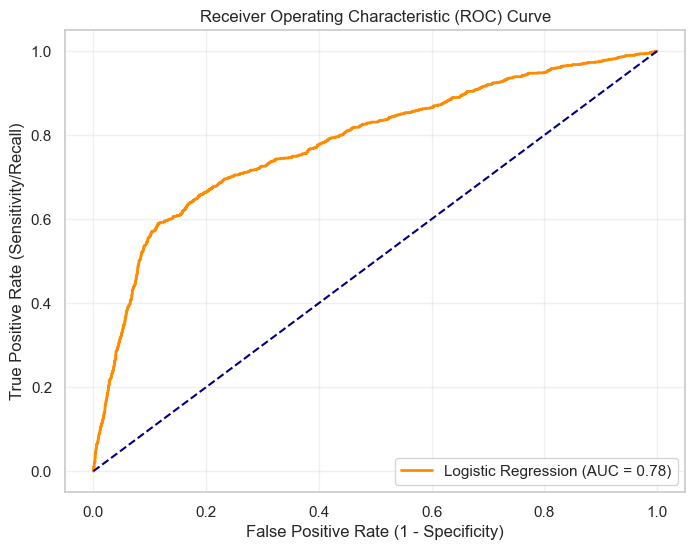

In [218]:
out_dir = 'Report\\Evaluation\\ROC_curves'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

recall = recall_score(y_test, y_pred)
y_proba = model.predict_proba(X_test_processed)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal baseline
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "ROC_of_LogisticRegression.png"))
plt.show()

In [219]:
importance = np.abs(model.coef_[0])

#### SHAP (SHapley Additive exPlanations).

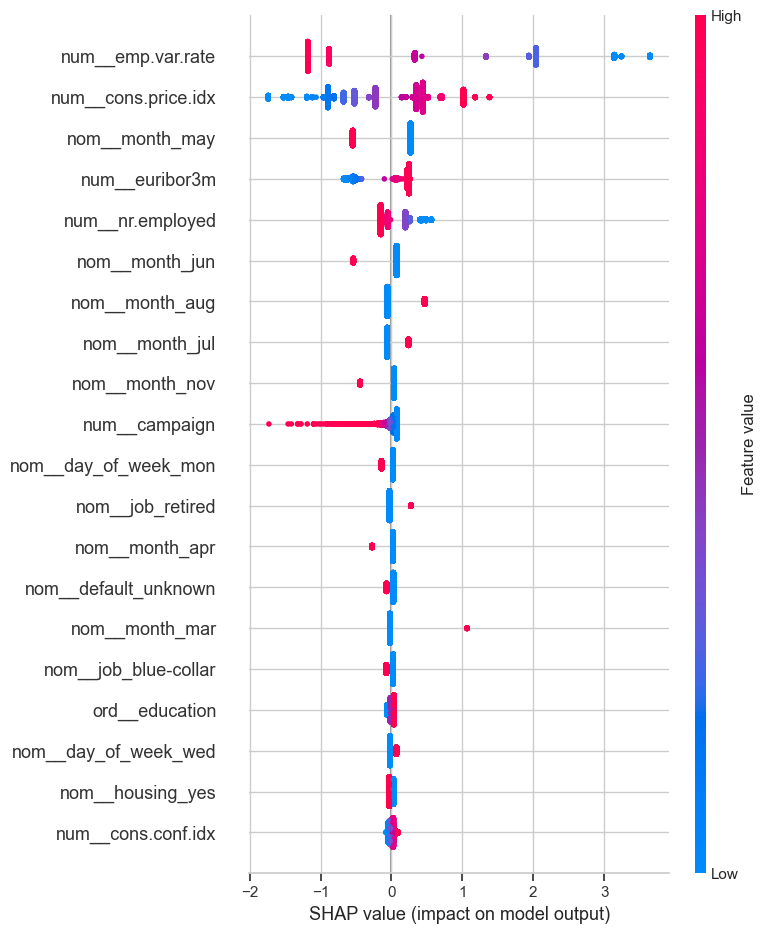

In [231]:
# Global Feature Importance
import shap

out_dir = 'Report\XAI'

feature_names = preprocessor.get_feature_names_out()

explainer = shap.LinearExplainer(model, X_train_processed)
shap_values = explainer(X_test_processed)

shap.summary_plot(
    shap_values.values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.savefig(os.path.join(out_dir, f"shap_plot.png"), dpi=300, bbox_inches="tight")



### Lime(Local Interpretable Model-agnostic Explanation)

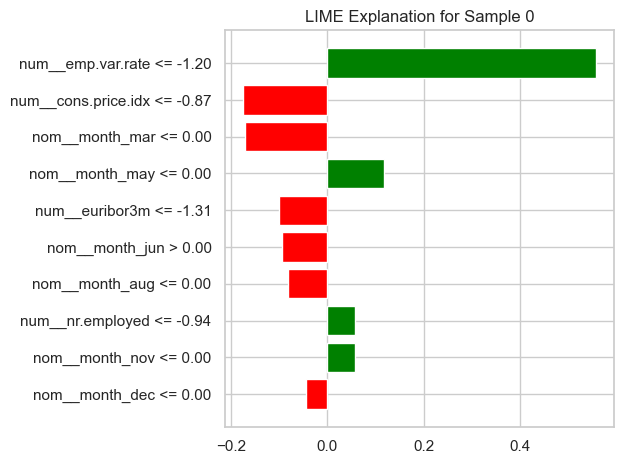

Actual: Yes
Predicted: Yes
Prediction Probabilities: [0.17810407 0.82189593]


In [221]:
import lime
import lime.lime_tabular

out_dir = 'Report\XAI'
# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    mode='classification'
)

# Explain a single prediction (change index to explore different samples)
sample_idx = 0  # Index of the test sample to explain
exp = lime_explainer.explain_instance(
    X_test_processed[sample_idx],
    model.predict_proba,
    num_features=10
)

# Display LIME explanation as a plot
fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation for Sample {sample_idx}')
plt.savefig(os.path.join(out_dir, f"lime_plot.png"), dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Print prediction details
print(f"Actual: {'Yes' if y_test.iloc[sample_idx] == 1 else 'No'}")
print(f"Predicted: {'Yes' if model.predict(X_test_processed[sample_idx].reshape(1, -1))[0] == 1 else 'No'}")
print(f"Prediction Probabilities: {model.predict_proba(X_test_processed[sample_idx].reshape(1, -1))[0]}")

#### Random Forrest

In [222]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_processed, y_train)

# 5. Predict and Evaluate
predictions = rf_model.predict(X_test_processed)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      7265
           1       0.36      0.30      0.33       971

    accuracy                           0.85      8236
   macro avg       0.63      0.62      0.62      8236
weighted avg       0.84      0.85      0.85      8236



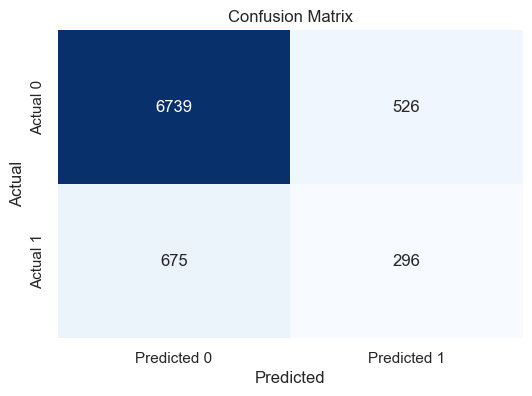

In [223]:
out_dir = 'Report\\Evaluation\\confusion_metircs'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(out_dir, "confusion_metrics_of_RandomForest.png"))
plt.show()

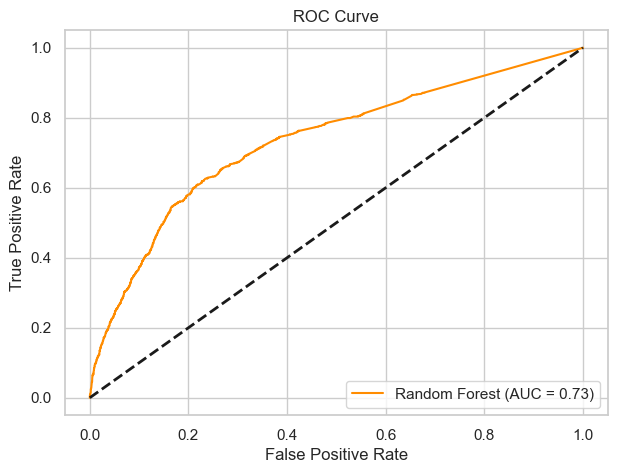

In [224]:
out_dir = 'Report\\Evaluation\\ROC_curves'

if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)

y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig(os.path.join(out_dir, "ROC_of_RandomForest.png"))
plt.show()

In [225]:
rf_model.feature_importances_

array([1.40230262e-01, 6.30245161e-02, 2.84402767e-02, 3.70638636e-02,
       1.89252747e-01, 6.84631725e-02, 2.37370258e-02, 1.92325472e-02,
       8.89939720e-03, 5.83334214e-03, 1.31300058e-02, 1.03948005e-02,
       8.54804504e-03, 1.43857153e-02, 6.13001872e-03, 1.90340852e-02,
       6.20498404e-03, 1.43709236e-02, 2.13981517e-02, 1.93968236e-02,
       3.26216575e-03, 2.29485396e-03, 3.40434075e-04, 2.84689200e-03,
       2.25397113e-03, 3.48412513e-03, 1.28877312e-02, 1.60172480e-03,
       6.41060058e-03, 2.11868648e-03, 1.63871527e-02, 1.64696183e-02,
       1.64370603e-02, 1.57931824e-02, 1.62426059e-02, 1.26013506e-02,
       1.42252367e-02, 3.15136864e-06, 2.22468693e-02, 2.27258950e-02,
       1.51255808e-02, 1.52869347e-02, 6.17834734e-02])

# SVM

In [226]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_train_processed, y_train)
predictions = svm.predict(X_test_processed)
y_proba_svm = svm.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[6195 1070]
 [ 381  590]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.90      7265
           1       0.36      0.61      0.45       971

    accuracy                           0.82      8236
   macro avg       0.65      0.73      0.67      8236
weighted avg       0.87      0.82      0.84      8236



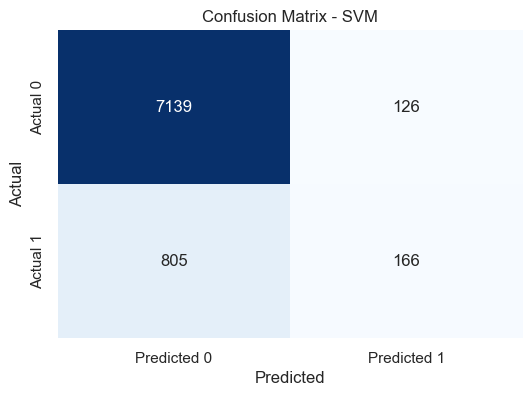

In [227]:
# Confusion Matrix
out_dir = 'Report/Evaluation/confusion_metircs'
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.savefig(os.path.join(out_dir, "confusion_metrics_of_SVM.png"))
plt.show()

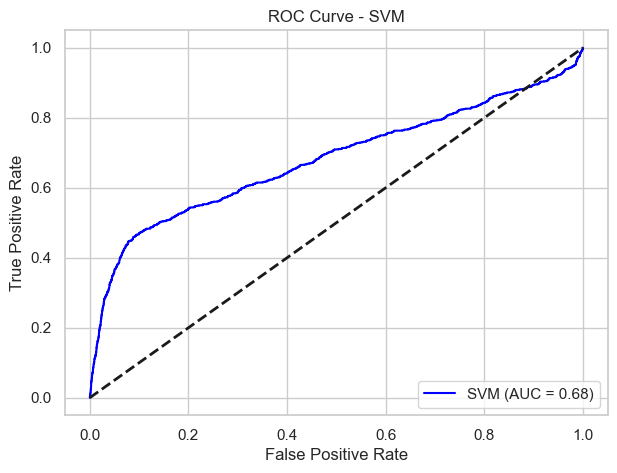

In [228]:
# ROC Curve
out_dir = 'Report/Evaluation/ROC_curves'
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.savefig(os.path.join(out_dir, "ROC_of_SVM.png"))
plt.show()